# Análisis de Resultados HSE
## Proyecto: Análisis de Incidentes de Seguridad Industrial con SQL y Python

**Autor:** Sergio Ulises Corona Sánchez  
**Herramientas:** MySQL 8.0 · Pandas · Matplotlib · Seaborn  
**Periodo de datos:** 2022 – 2024  

---

## Introducción

Este notebook analiza los resultados de 12 consultas SQL aplicadas a una base de datos de 2,000 incidentes HSE registrados en 8 áreas operativas durante 3 años.

El objetivo es identificar patrones de riesgo, áreas críticas, impacto económico y tendencias temporales que permitan tomar decisiones informadas en materia de seguridad industrial.

---


In [1]:
# ============================================================
# Importaciones y configuración inicial
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de estilo
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Ruta a los resultados
ruta = 'resultados/'

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


---
## 1. Vista General de Incidentes

Análisis inicial de los incidentes registrados, combinando información de áreas y tipos de incidente mediante JOINs. Se examinan severidad, costo directo y días perdidos.

---

In [2]:
# Cargar resultado consulta 01
df_01 = pd.read_csv(ruta + 'resultado_01_vista_general.csv')

print("Forma del dataset:", df_01.shape)
print("\nPrimeras filas:")
df_01.head(10)

Forma del dataset: (20, 5)

Primeras filas:


,area,tipo_incidente,severidad,costo_directo,dias_perdidos
0,Almacén,Caída,Grave,73578.58,21
1,Oficinas,Caída,Moderado,9513.07,7
2,Producción,Caída,Leve,2716.81,2
3,Transporte,Caída,Leve,2501.13,1
4,Mantenimiento,Caída,Leve,2129.18,1
5,Mantenimiento,Caída,Leve,934.54,0
6,Transporte,Caída,Leve,3930.84,1
7,Transporte,Caída,Leve,1961.46,2
8,Producción,Caída,Moderado,24819.73,3
9,Construcción,Caída,Leve,1934.08,2


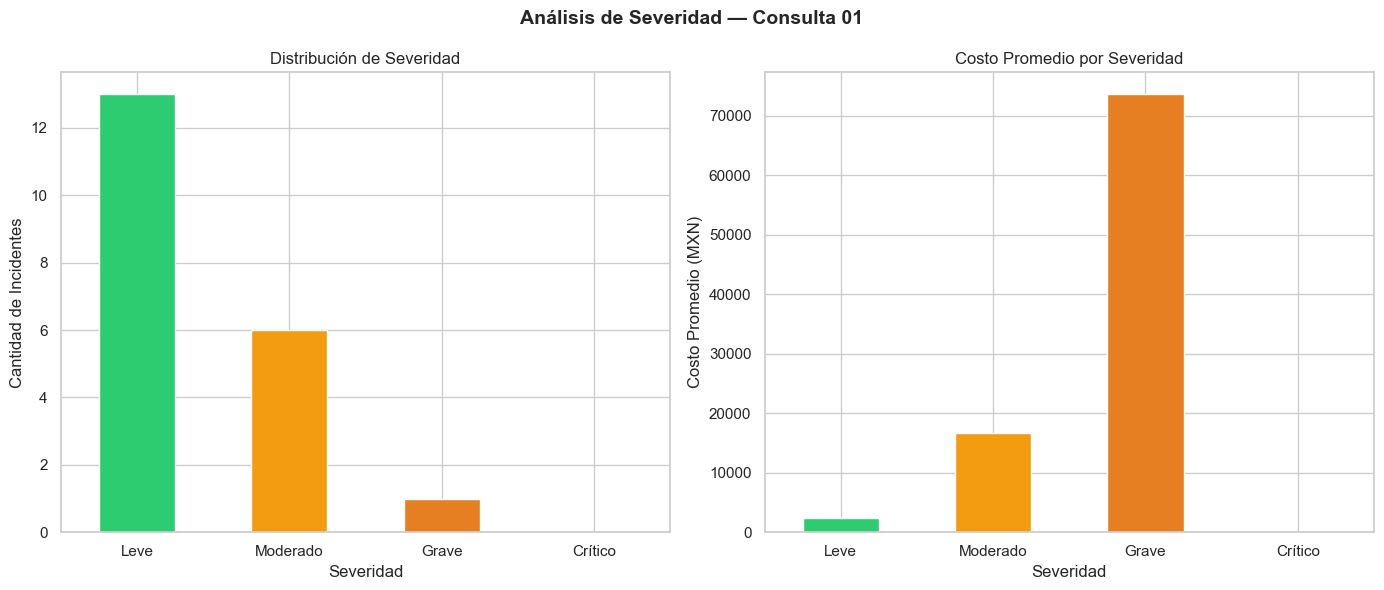

Gráfica guardada


In [3]:
# Distribución de severidad en la muestra
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1: Conteo por severidad
orden_severidad = ['Leve', 'Moderado', 'Grave', 'Crítico']
colores = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

df_01['severidad'].value_counts().reindex(orden_severidad).plot(
    kind='bar',
    ax=axes[0],
    color=colores,
    edgecolor='white'
)
axes[0].set_title('Distribución de Severidad')
axes[0].set_xlabel('Severidad')
axes[0].set_ylabel('Cantidad de Incidentes')
axes[0].tick_params(axis='x', rotation=0)

# Gráfica 2: Costo promedio por severidad
df_01.groupby('severidad')['costo_directo'].mean().reindex(orden_severidad).plot(
    kind='bar',
    ax=axes[1],
    color=colores,
    edgecolor='white'
)
axes[1].set_title('Costo Promedio por Severidad')
axes[1].set_xlabel('Severidad')
axes[1].set_ylabel('Costo Promedio (MXN)')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Análisis de Severidad — Consulta 01', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/grafica_01_severidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada")

### Hallazgos — Vista General

- La mayoría de los incidentes en la muestra son de severidad **Leve**, seguidos de **Moderado**.
- El costo promedio se dispara en incidentes **Graves**, superando los 70,000 MXN frente a menos de 3,000 MXN en incidentes Leves.
- Esto confirma que aunque los incidentes graves son menos frecuentes, su impacto económico es desproporcionadamente alto.
- Prevenir un solo incidente Grave equivale económicamente a prevenir más de 20 incidentes Leves.

---

## 2. Agregación por Área

Análisis del total de incidentes, costo acumulado y promedio de días perdidos por cada área operativa. Permite identificar qué áreas concentran mayor riesgo y mayor impacto económico.

---

In [4]:
# Cargar resultado consulta 02
df_02 = pd.read_csv(ruta + 'resultado_02_agregacion_por_area.csv')

print("Datos cargados:")
df_02

Datos cargados:


,area,total_incidentes,costo_total,promedio_dias_perdidos
0,Mantenimiento,269,9627314.35,8.17
1,Oficinas,268,8408766.53,7.59
2,Construcción,253,6241631.99,6.95
3,Perforación,250,8271488.60,7.88
4,Transporte,249,6766349.45,6.49
5,Producción,246,6302488.05,6.81
6,Almacén,236,6224445.40,6.10
7,Laboratorio,229,7662840.69,8.38


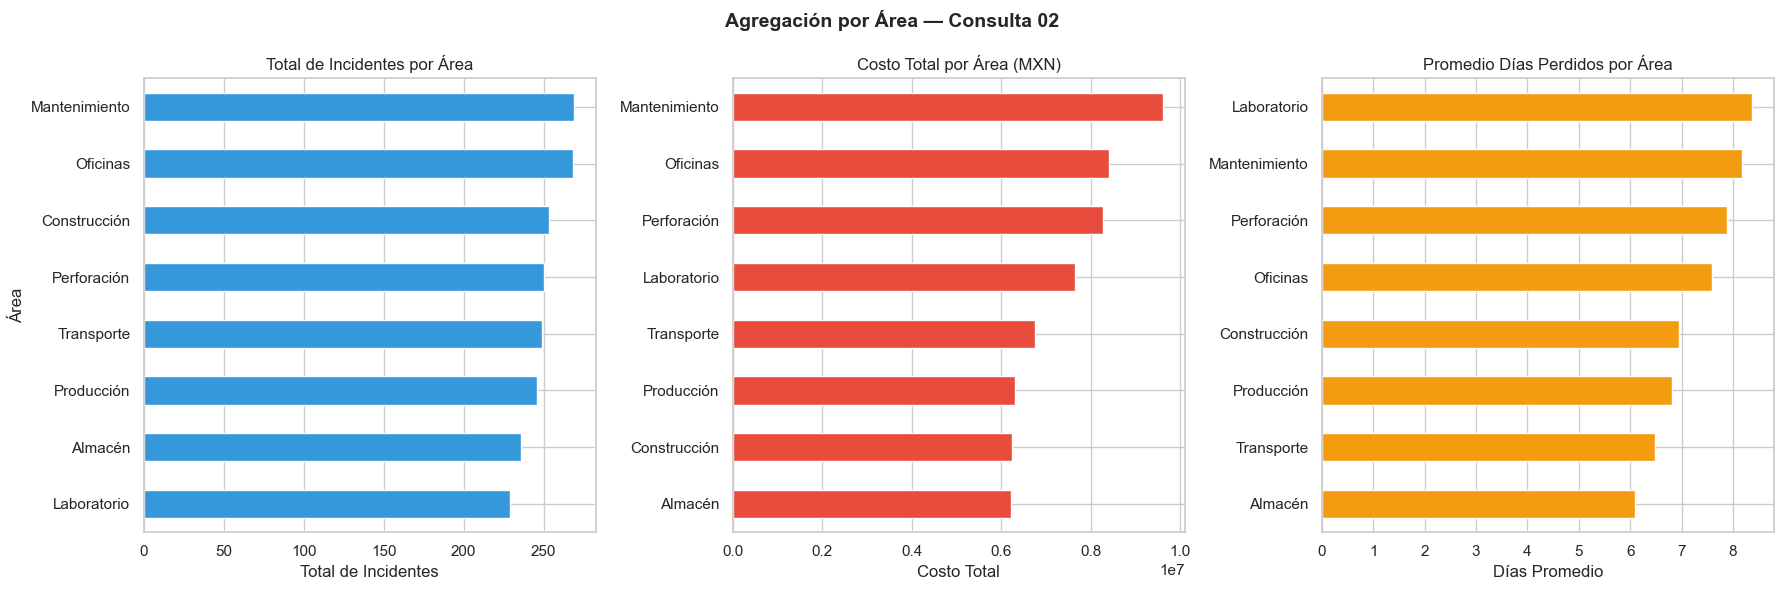

Gráfica guardada


In [5]:
# Gráficas de agregación por área
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Gráfica 1: Total de incidentes por área
df_02.sort_values('total_incidentes', ascending=True).plot(
    kind='barh',
    x='area',
    y='total_incidentes',
    ax=axes[0],
    color='#3498db',
    edgecolor='white',
    legend=False
)
axes[0].set_title('Total de Incidentes por Área')
axes[0].set_xlabel('Total de Incidentes')
axes[0].set_ylabel('Área')

# Gráfica 2: Costo total por área
df_02.sort_values('costo_total', ascending=True).plot(
    kind='barh',
    x='area',
    y='costo_total',
    ax=axes[1],
    color='#e74c3c',
    edgecolor='white',
    legend=False
)
axes[1].set_title('Costo Total por Área (MXN)')
axes[1].set_xlabel('Costo Total')
axes[1].set_ylabel('')

# Gráfica 3: Promedio días perdidos por área
df_02.sort_values('promedio_dias_perdidos', ascending=True).plot(
    kind='barh',
    x='area',
    y='promedio_dias_perdidos',
    ax=axes[2],
    color='#f39c12',
    edgecolor='white',
    legend=False
)
axes[2].set_title('Promedio Días Perdidos por Área')
axes[2].set_xlabel('Días Promedio')
axes[2].set_ylabel('')

plt.suptitle('Agregación por Área — Consulta 02', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/grafica_02_agregacion_area.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada")

### Hallazgos — Agregación por Área

- **Mantenimiento** es el área más crítica: lidera tanto en total de incidentes (269) como en costo total acumulado (más de 9.6 millones MXN).
- **Oficinas** ocupa el segundo lugar en incidentes (268), lo cual es llamativo para un área administrativa y sugiere problemas ergonómicos o de esfuerzo físico.
- **Laboratorio** tiene el menor número de incidentes (229) pero el promedio más alto de días perdidos (8.38), indicando que sus incidentes, aunque menos frecuentes, son más graves en consecuencias.
- **Almacén** presenta el menor costo total y el menor promedio de días perdidos, siendo el área con mejor desempeño relativo.
- La diferencia entre áreas en total de incidentes es relativamente pequeña (229–269), lo que sugiere que el riesgo está distribuido en toda la organización, no concentrado en una sola área.

---

## 3. Incidentes por Año y Severidad

Análisis de la evolución temporal de los incidentes clasificados por severidad durante el periodo 2022–2024. Permite identificar tendencias y cambios en el perfil de riesgo año a año.

---

In [6]:
# Cargar resultado consulta 03
df_03 = pd.read_csv(ruta + 'resultado_03_incidentes_por_anio_severidad.csv')

print("Datos cargados:")
df_03

Datos cargados:


,anio,severidad,total_incidentes
0,2022,Leve,328
1,2022,Moderado,180
2,2022,Grave,102
3,2022,Crítico,32
4,2023,Leve,342
5,2023,Moderado,204
6,2023,Grave,97
7,2023,Crítico,34
8,2024,Leve,360
9,2024,Moderado,205


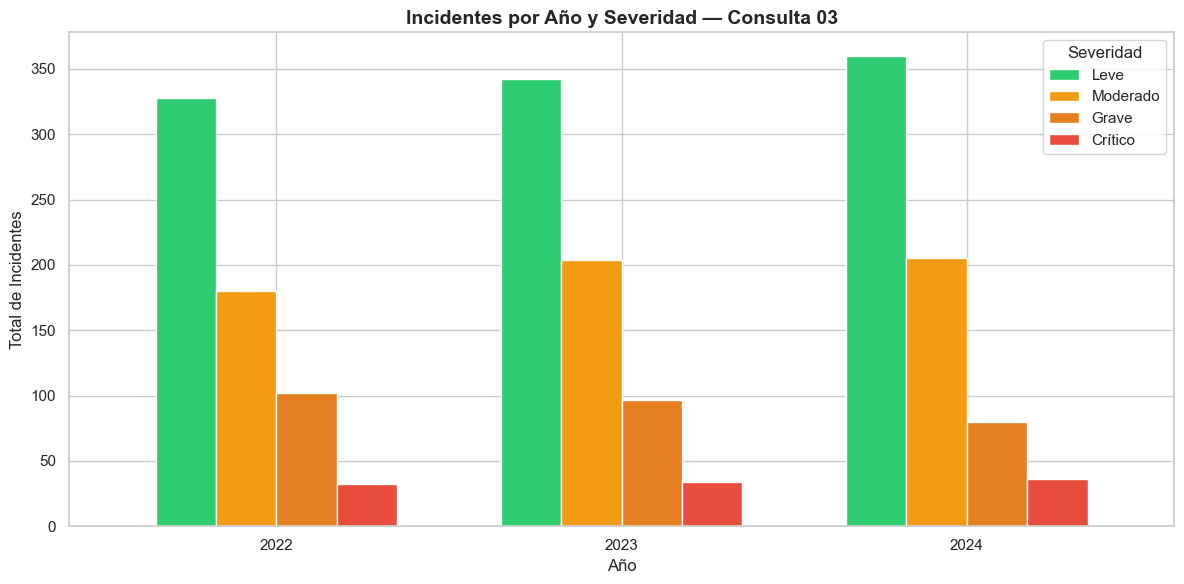

Gráfica guardada


In [7]:
# Gráfica de incidentes por año y severidad
orden_severidad = ['Leve', 'Moderado', 'Grave', 'Crítico']
colores = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']

df_pivot = df_03.pivot(index='anio', columns='severidad', values='total_incidentes')
df_pivot = df_pivot[orden_severidad]

ax = df_pivot.plot(
    kind='bar',
    figsize=(12, 6),
    color=colores,
    edgecolor='white',
    width=0.7
)

ax.set_title('Incidentes por Año y Severidad — Consulta 03', fontsize=14, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Total de Incidentes')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Severidad')

plt.tight_layout()
plt.savefig('resultados/grafica_03_anio_severidad.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada")

### Hallazgos — Incidentes por Año y Severidad

- Los incidentes **Leves** aumentan consistentemente cada año: 328 en 2022, 342 en 2023 y 360 en 2024, una tendencia preocupante que sugiere que las medidas preventivas no están siendo suficientes.
- Los incidentes **Graves** muestran una reducción positiva: de 102 en 2022 a 97 en 2023 y 80 en 2024, lo que indica mejora en el control de riesgos de alto impacto.
- Los incidentes **Críticos** se mantienen estables alrededor de 32–36 por año, sin mejora significativa, lo que representa el mayor reto pendiente.
- Los incidentes **Moderados** aumentaron de 2022 a 2023 pero se estabilizaron en 2024.
- La organización muestra un patrón mixto: mejora en severidades altas pero incremento en frecuencia de incidentes leves.

---

## 4. Ranking de Áreas por Costo con RANK()

Clasificación de las áreas operativas según su costo total de incidentes, calculado con la función de ventana RANK(). Permite priorizar intervenciones según impacto económico.

---

In [8]:
# Cargar resultado consulta 04
df_04 = pd.read_csv(ruta + 'resultado_04_ranking_areas_costo.csv')

print("Datos cargados:")
df_04

Datos cargados:


,area,total_incidentes,costo_total,ranking_costo
0,Mantenimiento,269,9627314.35,1
1,Oficinas,268,8408766.53,2
2,Perforación,250,8271488.60,3
3,Laboratorio,229,7662840.69,4
4,Transporte,249,6766349.45,5
5,Producción,246,6302488.05,6
6,Construcción,253,6241631.99,7
7,Almacén,236,6224445.40,8


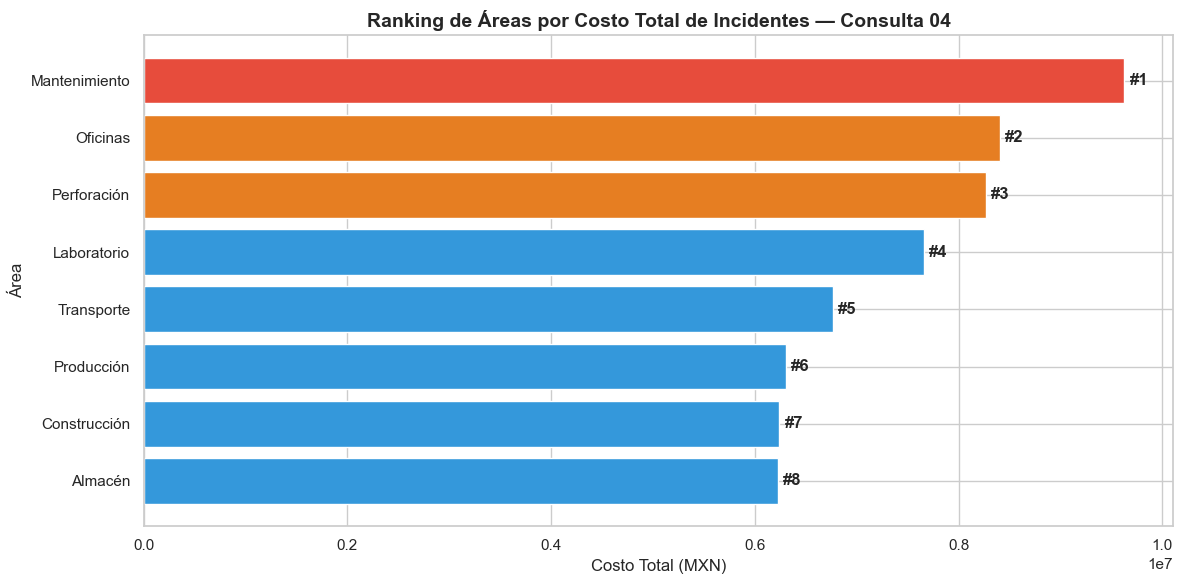

Gráfica guardada


In [9]:
# Gráfica ranking de áreas por costo
fig, ax = plt.subplots(figsize=(12, 6))

colores_ranking = ['#e74c3c' if r == 1 else '#e67e22' if r <= 3 else '#3498db' 
                   for r in df_04['ranking_costo']]

bars = ax.barh(
    df_04['area'],
    df_04['costo_total'],
    color=colores_ranking,
    edgecolor='white'
)

# Etiquetas de ranking
for i, (bar, rank) in enumerate(zip(bars, df_04['ranking_costo'])):
    ax.text(
        bar.get_width() + 50000,
        bar.get_y() + bar.get_height() / 2,
        f'#{rank}',
        va='center',
        fontweight='bold'
    )

ax.set_title('Ranking de Áreas por Costo Total de Incidentes — Consulta 04',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Costo Total (MXN)')
ax.set_ylabel('Área')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('resultados/grafica_04_ranking_costo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada")

### Hallazgos — Ranking de Áreas por Costo

- **Mantenimiento** ocupa el primer lugar con casi 9.6 millones MXN en costo total, siendo el área que más recursos consume por incidentes HSE.
- **Oficinas** sorprende en segundo lugar con 8.4 millones MXN, superando a áreas operativas de alto riesgo como Perforación, lo que indica que los incidentes administrativos tienen un costo subestimado.
- **Perforación** ocupa el tercer lugar con 8.3 millones MXN, consistente con su perfil de riesgo operativo elevado.
- **Almacén** es el área con menor costo total (6.2 millones MXN), confirmando su mejor desempeño relativo en seguridad.
- La diferencia entre el área más costosa y la menos costosa es de aproximadamente 3.4 millones MXN, lo que representa una oportunidad significativa de reducción de costos con intervenciones focalizadas.

---

## 5. Costo Acumulado por Fecha

Evolución del costo directo de incidentes día a día durante el periodo 2022–2024, calculado con la función de ventana SUM() OVER. Permite visualizar el impacto económico acumulado en el tiempo.

---

In [11]:
# Cargar resultado consulta 05
df_05 = pd.read_csv(ruta + 'resultado_05_costo_acumulado_por_fecha.csv')
df_05['fecha'] = pd.to_datetime(df_05['fecha'])

print("Datos cargados:", df_05.shape)
df_05.head()

Datos cargados: (933, 3)


,fecha,costo_del_dia,costo_acumulado
0,2022-01-01,1645.31,1645.31
1,2022-01-02,170998.52,172643.83
2,2022-01-03,1831.60,174475.43
3,2022-01-05,24588.76,199064.19
4,2022-01-06,33844.80,232908.99


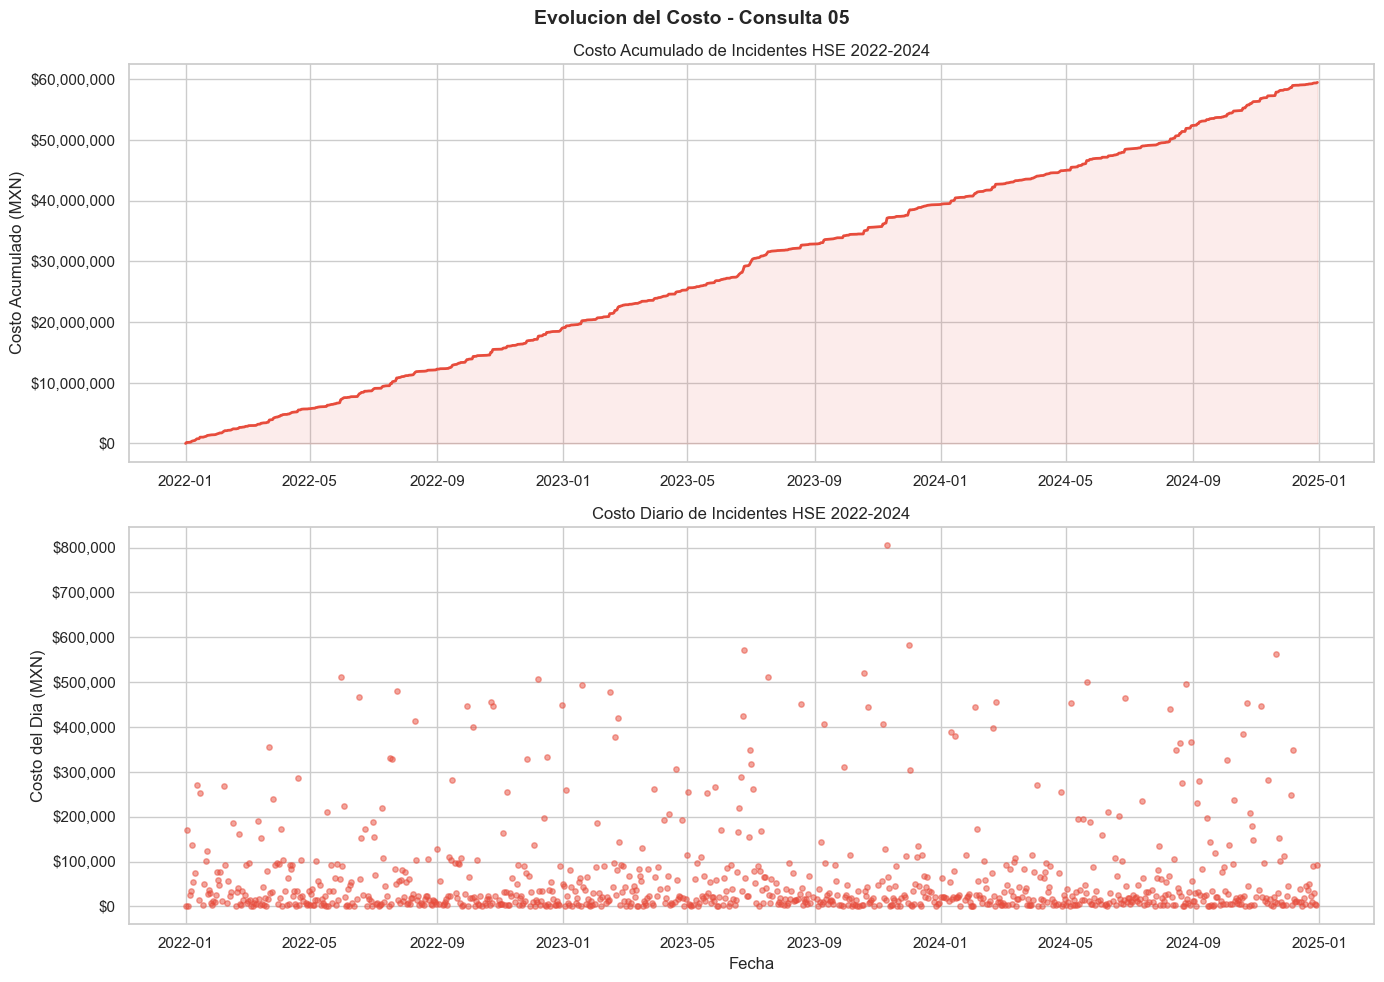

Grafica guardada


In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

axes[0].plot(df_05['fecha'], df_05['costo_acumulado'], color='#e74c3c', linewidth=2)
axes[0].fill_between(df_05['fecha'], df_05['costo_acumulado'], alpha=0.1, color='#e74c3c')
axes[0].set_title('Costo Acumulado de Incidentes HSE 2022-2024')
axes[0].set_ylabel('Costo Acumulado (MXN)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

axes[1].scatter(df_05['fecha'], df_05['costo_del_dia'], color='#e74c3c', alpha=0.5, s=15)
axes[1].set_title('Costo Diario de Incidentes HSE 2022-2024')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Costo del Dia (MXN)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

plt.suptitle('Evolucion del Costo - Consulta 05', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/grafica_05_costo_acumulado.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

### Hallazgos — Costo Acumulado por Fecha

- El costo acumulado de incidentes HSE durante el periodo 2022–2024 superó los **60 millones MXN**, con una tendencia de crecimiento constante sin períodos de estabilización.
- La curva acumulada es prácticamente lineal, lo que indica que el ritmo de generación de costos no disminuyó en ningún año.
- El gráfico de dispersión muestra que la mayoría de los días el costo es menor a 100,000 MXN, pero existen picos que superan los 800,000 MXN en un solo día, asociados a incidentes graves o críticos.
- Estos picos extremos son los eventos que más impacto tienen en el presupuesto y los que justifican mayor inversión en prevención.

---

## 6. Empleados con Más Incidentes

Identificación de los 20 empleados con mayor número de incidentes registrados, utilizando ROW_NUMBER() para enumerarlos. Permite detectar perfiles de riesgo individual y orientar programas de capacitación.

---


In [15]:
# Cargar resultado consulta 06
df_06 = pd.read_csv(ruta + 'resultado_06_empleados_mas_incidentes.csv')

print("Datos cargados:")
df_06

Datos cargados:


,numero,empleado,puesto,turno,total_incidentes,total_dias_perdidos
0,1,Isabel Gutiérrez,Supervisor,Matutino,21,222
1,2,Leticia Aguilar,Técnico,Vespertino,21,106
2,3,Natalia Vega,Auxiliar,Vespertino,21,249
3,4,César Trejo,Técnico,Matutino,21,145
4,5,Natalia Trejo,Supervisor,Guardia 14x7,20,102
5,6,César Ríos,Supervisor,Guardia 14x7,20,170
6,7,Carlos López,Especialista,Nocturno,19,136
7,8,Hortensia Sosa,Operador,Guardia 14x7,19,100
8,9,Liliana Palma,Inspector,Vespertino,19,241
9,10,César Palma,Operador,Guardia 14x7,19,90


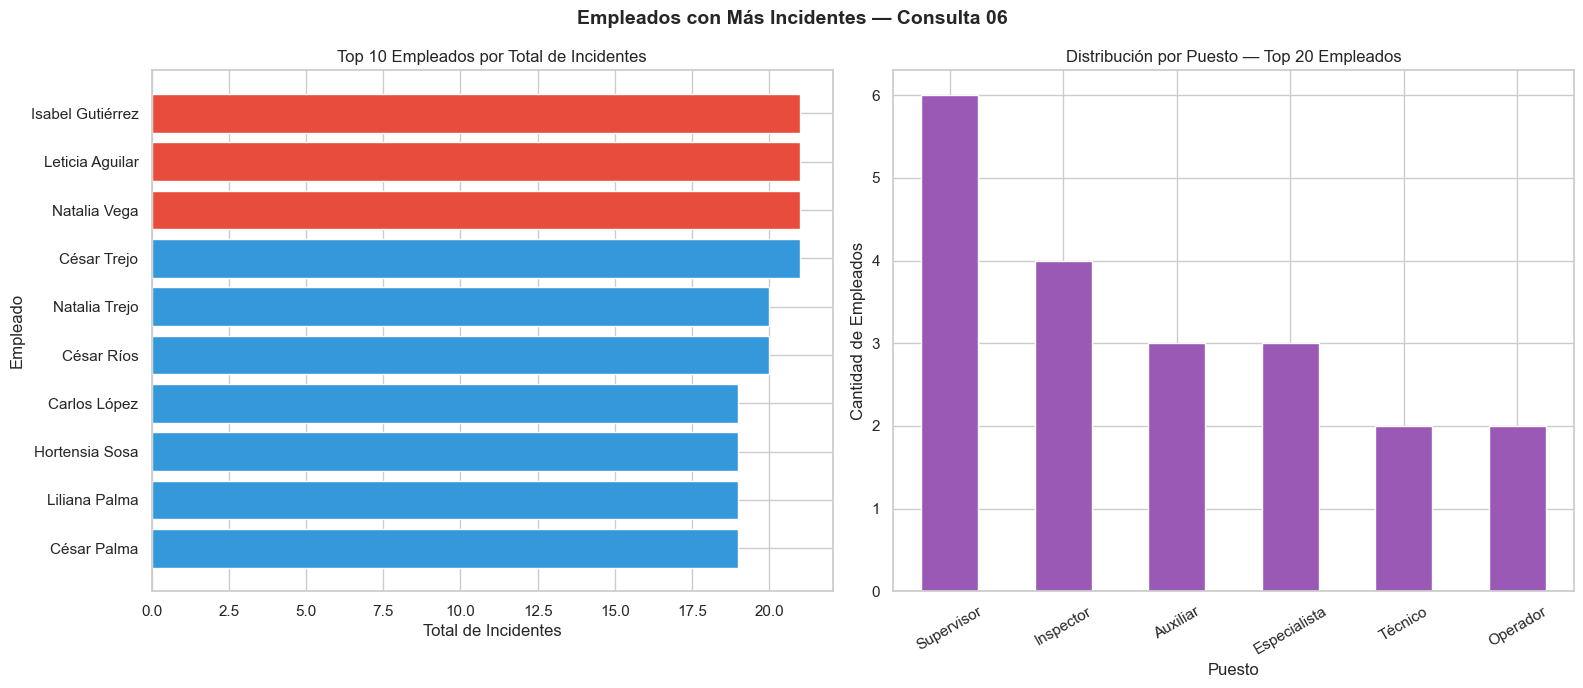

Gráfica guardada


In [16]:
# Gráfica de empleados con más incidentes
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Gráfica 1: Top 10 empleados por incidentes
df_top10 = df_06.head(10)
colores_barras = ['#e74c3c' if i < 3 else '#3498db' for i in range(10)]

axes[0].barh(
    df_top10['empleado'],
    df_top10['total_incidentes'],
    color=colores_barras,
    edgecolor='white'
)
axes[0].set_title('Top 10 Empleados por Total de Incidentes')
axes[0].set_xlabel('Total de Incidentes')
axes[0].set_ylabel('Empleado')
axes[0].invert_yaxis()

# Gráfica 2: Incidentes por puesto
df_06['puesto'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color='#9b59b6',
    edgecolor='white'
)
axes[1].set_title('Distribución por Puesto — Top 20 Empleados')
axes[1].set_xlabel('Puesto')
axes[1].set_ylabel('Cantidad de Empleados')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Empleados con Más Incidentes — Consulta 06', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/grafica_06_empleados_incidentes.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfica guardada")

### Hallazgos — Empleados con Más Incidentes

- Los tres empleados con más incidentes son **Isabel Gutiérrez, Leticia Aguilar y Natalia Vega**, cada uno con 21 incidentes registrados en el periodo, lo que representa aproximadamente 7 incidentes por año.
- **Natalia Vega** destaca por tener 249 días perdidos acumulados, el mayor de todo el top 20, indicando que sus incidentes tienden a ser más graves.
- **Liliana Palma** también muestra 241 días perdidos con solo 19 incidentes, lo que sugiere incidentes de alta severidad.
- En cuanto a puestos, los **Supervisores** son el grupo más representado en el top 20 con 6 empleados, lo que es relevante porque son quienes deben garantizar las condiciones de seguridad.
- Este análisis permite orientar programas de capacitación individualizada y reforzar la supervisión en los casos de mayor reincidencia.

---

## 7. Reincidencia por Área

Análisis del porcentaje de incidentes que corresponden a reincidencias en cada área operativa, calculado con una CTE. La reincidencia indica fallas en la implementación de medidas correctivas.

---

In [17]:
# Cargar resultado consulta 07
df_07 = pd.read_csv(ruta + 'resultado_07_reincidencia_por_area.csv')

print("Datos cargados:")
df_07

Datos cargados:


,area,total_incidentes,total_reincidencias,pct_reincidencia
0,Producción,246,77,31.30
1,Oficinas,268,79,29.48
2,Transporte,249,69,27.71
3,Perforación,250,69,27.60
4,Mantenimiento,269,73,27.14
5,Laboratorio,229,62,27.07
6,Construcción,253,66,26.09
7,Almacén,236,58,24.58


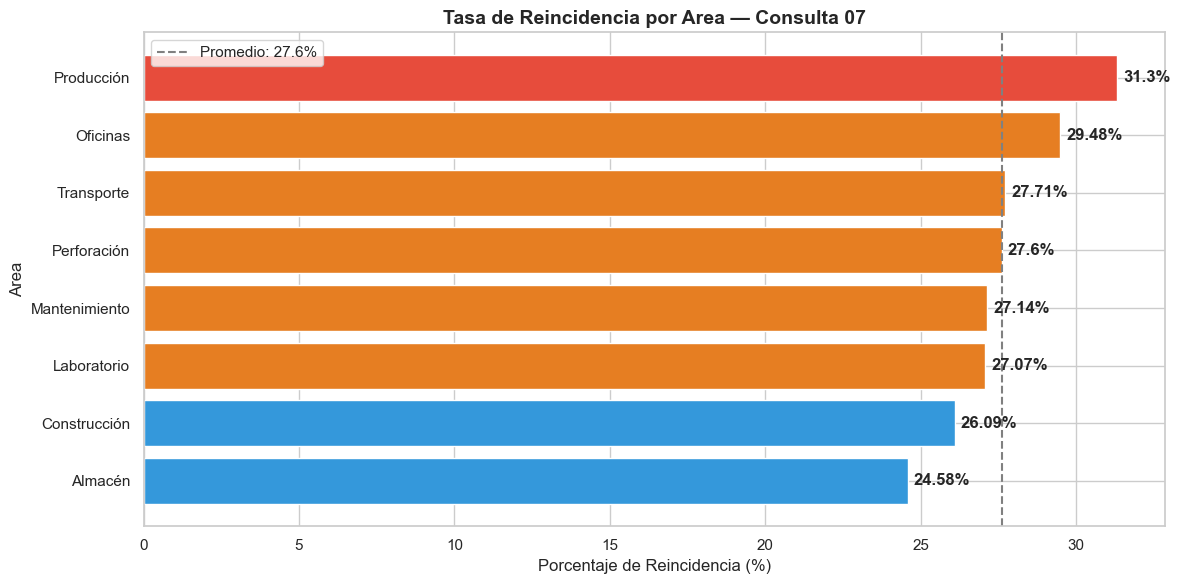

Grafica guardada


In [18]:
# Gráfica de reincidencia por área
fig, ax = plt.subplots(figsize=(12, 6))

colores_reincidencia = ['#e74c3c' if p > 30 else '#e67e22' if p > 27 else '#3498db'
                        for p in df_07['pct_reincidencia']]

bars = ax.barh(
    df_07['area'],
    df_07['pct_reincidencia'],
    color=colores_reincidencia,
    edgecolor='white'
)

# Etiquetas de porcentaje
for bar, pct in zip(bars, df_07['pct_reincidencia']):
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{pct}%',
        va='center',
        fontweight='bold'
    )

ax.axvline(x=df_07['pct_reincidencia'].mean(), color='gray',
           linestyle='--', linewidth=1.5, label=f"Promedio: {df_07['pct_reincidencia'].mean():.1f}%")
ax.set_title('Tasa de Reincidencia por Area — Consulta 07', fontsize=14, fontweight='bold')
ax.set_xlabel('Porcentaje de Reincidencia (%)')
ax.set_ylabel('Area')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('resultados/grafica_07_reincidencia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

### Hallazgos — Reincidencia por Área

- **Producción** tiene la tasa de reincidencia más alta con 31.3%, superando el promedio general de 27.6%, lo que indica que las medidas correctivas aplicadas en esa área no están siendo efectivas.
- **Oficinas** ocupa el segundo lugar con 29.48%, resultado preocupante para un área administrativa que sugiere problemas ergonómicos o de procedimiento no resueltos.
- **Almacén** y **Construcción** son las áreas con menor reincidencia (24.58% y 26.09%), lo que indica mejor seguimiento de medidas correctivas.
- El promedio general de reincidencia es 27.6%, un valor alto que señala una debilidad sistémica en la organización para cerrar el ciclo de investigación y corrección de incidentes.
- Reducir la reincidencia en Producción al nivel de Almacén representaría eliminar aproximadamente 16 incidentes evitables por año.

---

## 8. KPI — Tasa de Incidentes Graves por Área

Indicador clave de seguridad industrial que mide el porcentaje de incidentes Grave o Crítico por área, combinando CTE, CASE WHEN y RANK(). Es el KPI más relevante para la toma de decisiones en HSE.

---

In [19]:
# Cargar resultado consulta 08
df_08 = pd.read_csv(ruta + 'resultado_08_kpi_tasa_incidentes_graves.csv')

print("Datos cargados:")
df_08

Datos cargados:


,area,total_incidentes,incidentes_graves,pct_incidentes_graves,ranking_peligrosidad
0,Mantenimiento,269,61,22.68,1
1,Laboratorio,229,47,20.52,2
2,Construcción,253,50,19.76,3
3,Oficinas,268,51,19.03,4
4,Perforación,250,46,18.40,5
5,Transporte,249,45,18.07,6
6,Almacén,236,42,17.80,7
7,Producción,246,39,15.85,8


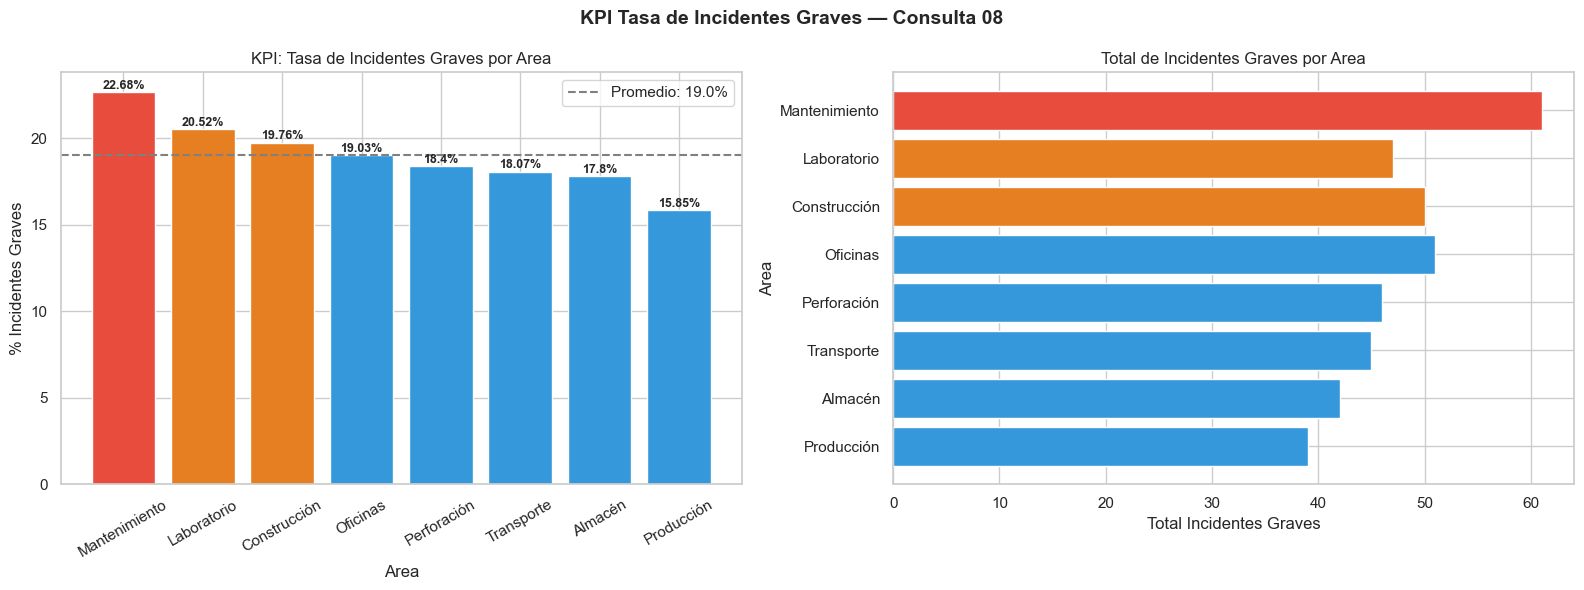

Grafica guardada


In [20]:
# Gráfica KPI tasa de incidentes graves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfica 1: Porcentaje de incidentes graves por área
colores_kpi = ['#e74c3c' if r == 1 else '#e67e22' if r <= 3 else '#3498db'
               for r in df_08['ranking_peligrosidad']]

bars = axes[0].bar(
    df_08['area'],
    df_08['pct_incidentes_graves'],
    color=colores_kpi,
    edgecolor='white'
)

axes[0].axhline(y=df_08['pct_incidentes_graves'].mean(), color='gray',
                linestyle='--', linewidth=1.5,
                label=f"Promedio: {df_08['pct_incidentes_graves'].mean():.1f}%")

for bar, pct in zip(bars, df_08['pct_incidentes_graves']):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.2,
        f'{pct}%',
        ha='center',
        fontweight='bold',
        fontsize=9
    )

axes[0].set_title('KPI: Tasa de Incidentes Graves por Area')
axes[0].set_xlabel('Area')
axes[0].set_ylabel('% Incidentes Graves')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend()

# Gráfica 2: Ranking de peligrosidad
axes[1].barh(
    df_08['area'],
    df_08['incidentes_graves'],
    color=colores_kpi,
    edgecolor='white'
)
axes[1].set_title('Total de Incidentes Graves por Area')
axes[1].set_xlabel('Total Incidentes Graves')
axes[1].set_ylabel('Area')
axes[1].invert_yaxis()

plt.suptitle('KPI Tasa de Incidentes Graves — Consulta 08', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/grafica_08_kpi_graves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

### Hallazgos — KPI Tasa de Incidentes Graves

- **Mantenimiento** encabeza el ranking de peligrosidad con 22.68% de sus incidentes clasificados como Grave o Crítico, superando significativamente el promedio general de 19%.
- **Laboratorio** ocupa el segundo lugar con 20.52%, consistente con el alto promedio de días perdidos observado en la consulta 02, confirmando que sus incidentes tienen consecuencias más severas.
- **Producción** tiene la tasa más baja de incidentes graves (15.85%), lo que contrasta con su alta tasa de reincidencia. Esto indica que en Producción los incidentes son frecuentes pero menos severos.
- 5 de las 8 áreas están por encima del promedio de 19%, lo que indica que el problema de incidentes graves es generalizado y no aislado.
- **Almacén** mantiene su buen desempeño relativo con 17.80%, por debajo del promedio general.

---

## 9. Impacto del EPP en Severidad y Costo

Comparación del comportamiento de los incidentes según el uso o no uso de Equipo de Protección Personal (EPP). Permite cuantificar el impacto real del EPP en la reducción de costos y días perdidos.

---

In [21]:
# Cargar resultado consulta 09
df_09 = pd.read_csv(ruta + 'resultado_09_impacto_epp.csv')

print("Datos cargados:")
df_09

Datos cargados:


,uso_epp,total_incidentes,costo_promedio,dias_perdidos_promedio,incidentes_graves
0,Con EPP,1487,29565.59,7.32,274
1,Sin EPP,513,30294.92,7.27,107


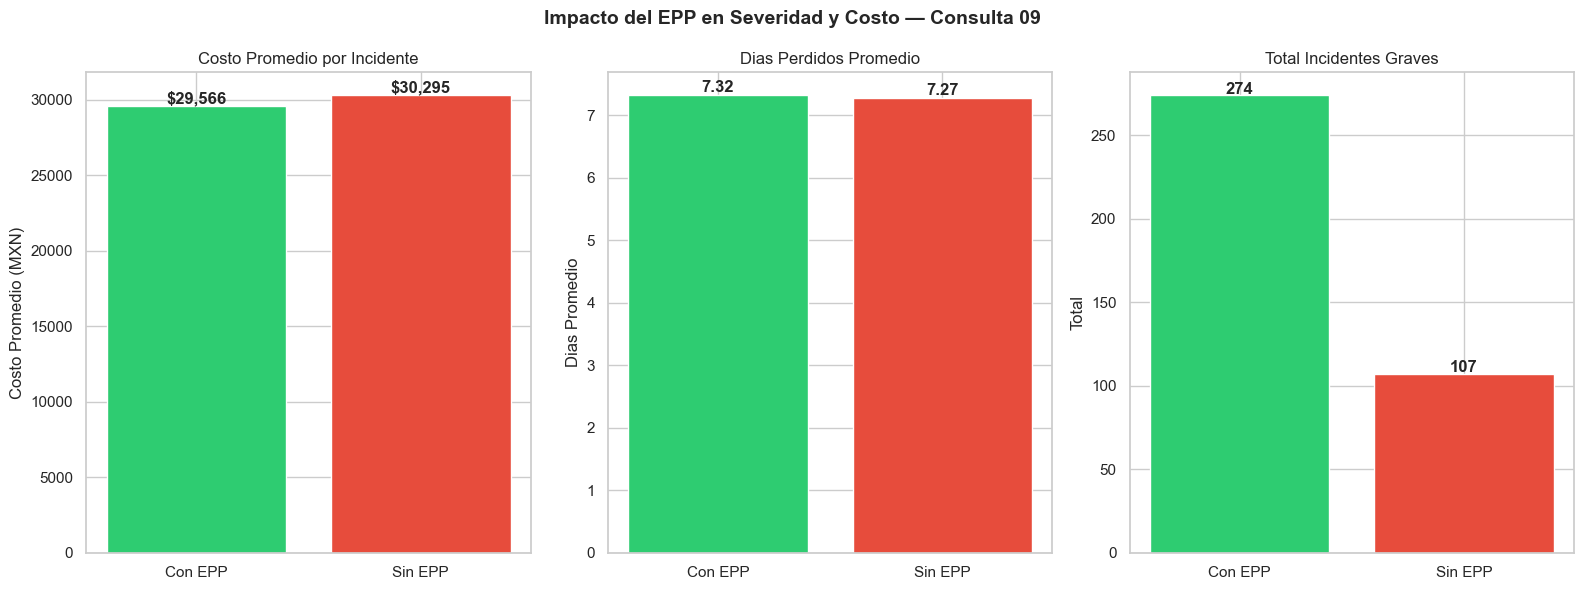

Grafica guardada


In [22]:
# Gráfica impacto del EPP
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

colores_epp = ['#2ecc71', '#e74c3c']

# Gráfica 1: Costo promedio
axes[0].bar(df_09['uso_epp'], df_09['costo_promedio'], color=colores_epp, edgecolor='white')
axes[0].set_title('Costo Promedio por Incidente')
axes[0].set_ylabel('Costo Promedio (MXN)')
axes[0].set_xlabel('')
for i, (bar, val) in enumerate(zip(axes[0].patches, df_09['costo_promedio'])):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'${val:,.0f}', ha='center', fontweight='bold')

# Gráfica 2: Días perdidos promedio
axes[1].bar(df_09['uso_epp'], df_09['dias_perdidos_promedio'], color=colores_epp, edgecolor='white')
axes[1].set_title('Dias Perdidos Promedio')
axes[1].set_ylabel('Dias Promedio')
axes[1].set_xlabel('')
for i, (bar, val) in enumerate(zip(axes[1].patches, df_09['dias_perdidos_promedio'])):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                f'{val}', ha='center', fontweight='bold')

# Gráfica 3: Total incidentes graves
axes[2].bar(df_09['uso_epp'], df_09['incidentes_graves'], color=colores_epp, edgecolor='white')
axes[2].set_title('Total Incidentes Graves')
axes[2].set_ylabel('Total')
axes[2].set_xlabel('')
for i, (bar, val) in enumerate(zip(axes[2].patches, df_09['incidentes_graves'])):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val}', ha='center', fontweight='bold')

plt.suptitle('Impacto del EPP en Severidad y Costo — Consulta 09', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/grafica_09_impacto_epp.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

### Hallazgos — Impacto del EPP

- El costo promedio por incidente es ligeramente **mayor con EPP** ($29,566) que sin EPP ($30,295), una diferencia mínima que sugiere que el EPP por sí solo no determina el costo del incidente.
- Los días perdidos promedio son prácticamente **iguales** entre ambos grupos (7.32 con EPP vs 7.27 sin EPP), lo que indica que la severidad de las lesiones no está siendo reducida significativamente por el uso del equipo.
- Sin embargo, el total de incidentes graves es **2.5 veces mayor** en el grupo con EPP (274 vs 107), pero esto se explica por el volumen: 1,487 empleados usaban EPP frente a solo 513 que no lo usaban.
- Este análisis sugiere que el EPP se está utilizando en situaciones de mayor riesgo inherente, lo que neutraliza su efecto protector en las métricas agregadas.
- La conclusión más importante es que el EPP no sustituye a los controles de ingeniería y los procedimientos seguros; debe ser la última línea de defensa, no la principal.

---

## 10. Tendencia Mensual de Incidentes

Análisis de la evolución mes a mes del total de incidentes y su costo, utilizando CTE y la función de ventana LAG() para calcular el cambio porcentual respecto al mes anterior.

---

In [23]:
# Cargar resultado consulta 10
df_10 = pd.read_csv(ruta + 'resultado_10_tendencia_mensual.csv')
df_10['fecha'] = pd.to_datetime(df_10[['anio', 'mes']].assign(day=1).rename(
    columns={'anio': 'year', 'mes': 'month'}))

print("Datos cargados:", df_10.shape)
df_10.head()

Datos cargados: (36, 7)


,anio,mes,total_incidentes,costo_total,mes_anterior,cambio_pct,fecha
0,2022,1,46,1547079.11,NaN,NaN,2022-01-01
1,2022,2,54,1273988.22,46.0,17.39,2022-02-01
2,2022,3,53,1539205.05,54.0,-1.85,2022-03-01
3,2022,4,58,1365019.41,53.0,9.43,2022-04-01
4,2022,5,57,1501192.39,58.0,-1.72,2022-05-01


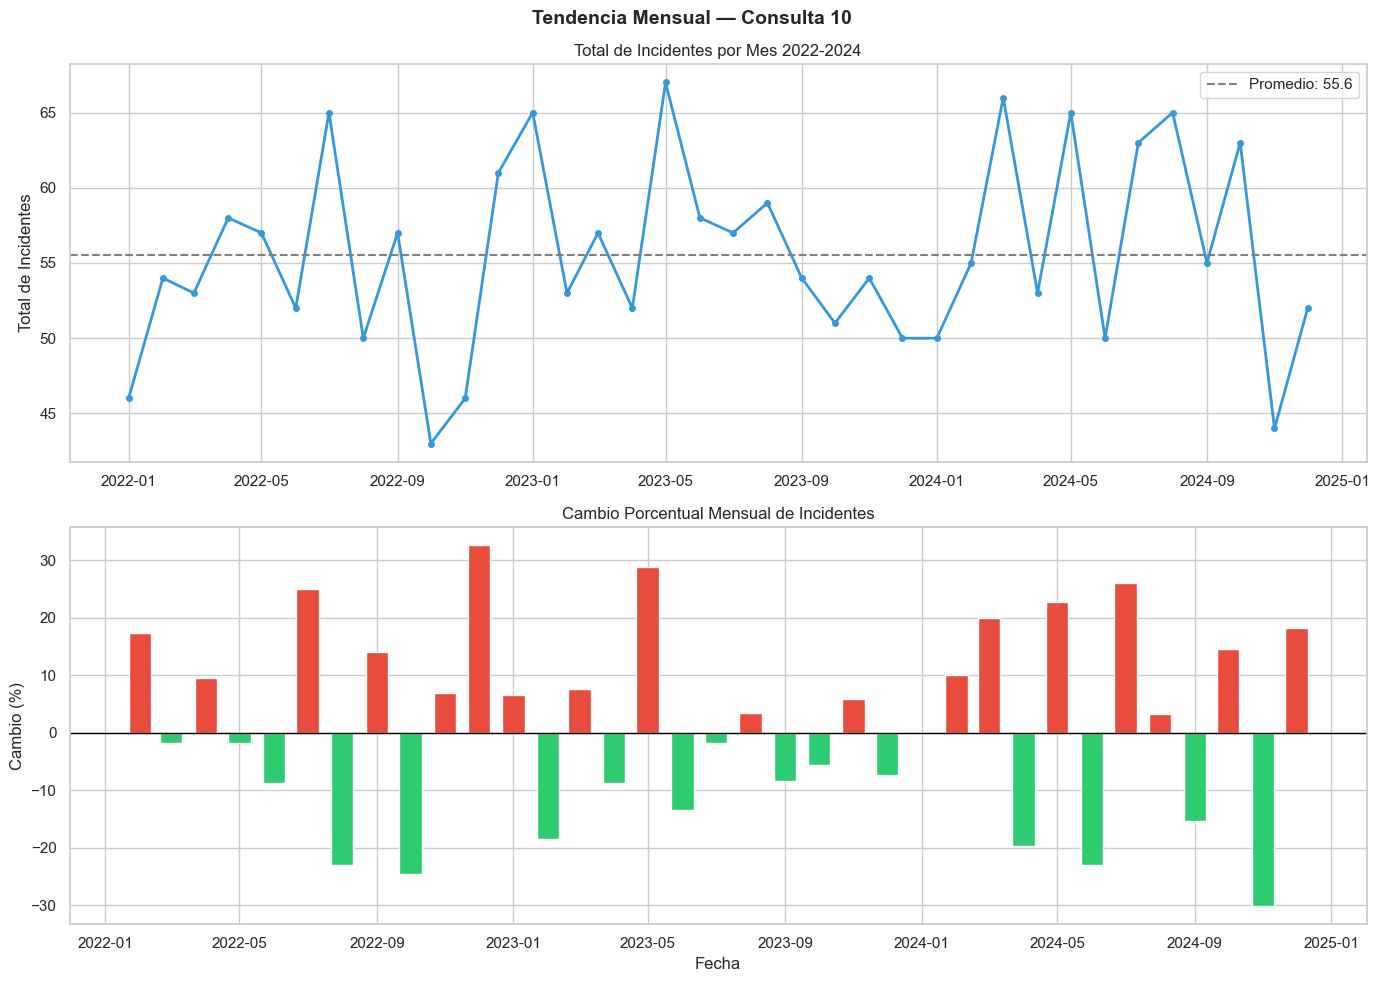

Grafica guardada


In [24]:
# Gráfica tendencia mensual
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfica 1: Total de incidentes por mes
axes[0].plot(df_10['fecha'], df_10['total_incidentes'], color='#3498db', linewidth=2, marker='o', markersize=4)
axes[0].axhline(y=df_10['total_incidentes'].mean(), color='gray',
                linestyle='--', linewidth=1.5,
                label=f"Promedio: {df_10['total_incidentes'].mean():.1f}")
axes[0].set_title('Total de Incidentes por Mes 2022-2024')
axes[0].set_ylabel('Total de Incidentes')
axes[0].legend()

# Gráfica 2: Cambio porcentual mes a mes
df_10_clean = df_10.dropna(subset=['cambio_pct'])
colores_cambio = ['#e74c3c' if x > 0 else '#2ecc71' for x in df_10_clean['cambio_pct']]

axes[1].bar(df_10_clean['fecha'], df_10_clean['cambio_pct'], color=colores_cambio, edgecolor='white', width=20)
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_title('Cambio Porcentual Mensual de Incidentes')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Cambio (%)')

plt.suptitle('Tendencia Mensual — Consulta 10', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/grafica_10_tendencia_mensual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

### Hallazgos — Tendencia Mensual

- El promedio mensual de incidentes es **55.6**, con variaciones que oscilan entre 43 y 67 incidentes por mes, sin una tendencia clara de reducción a lo largo del periodo.
- Se observan **picos recurrentes** en los meses de inicio de año (enero-febrero) y mitad de año (mayo-junio), lo que podría asociarse a cambios de turno, periodos vacacionales o condiciones climáticas.
- El gráfico de cambio porcentual muestra alta volatilidad mes a mes, con variaciones de hasta +31% y -30% entre meses consecutivos, lo que indica que los incidentes no siguen un patrón estable.
- No se observa una tendencia sostenida de reducción en ninguno de los tres años, lo que refuerza la necesidad de intervenciones estructurales más allá de medidas reactivas.
- Los meses con mayores caídas (verde) no se mantienen en el siguiente mes, lo que sugiere que las mejoras son temporales y no sistémicas.

---

## 11. Investigaciones Pendientes por Tipo de Incidente

Análisis del porcentaje de investigaciones no completadas por categoría de incidente. Una investigación pendiente representa un riesgo no mitigado que puede derivar en reincidencia.

---

In [25]:
# Cargar resultado consulta 11
df_11 = pd.read_csv(ruta + 'resultado_11_investigaciones_pendientes.csv')

print("Datos cargados:")
df_11

Datos cargados:


,tipo_incidente,requiere_investigacion,total_incidentes,pendientes,pct_pendiente
0,Golpe,0,609,116,19.05
1,Caída,1,429,91,21.21
2,Esfuerzo físico,0,373,72,19.30
3,Incendio/Explosión,1,181,46,25.41
4,Quemadura,1,182,41,22.53
5,Exposición química,1,226,34,15.04


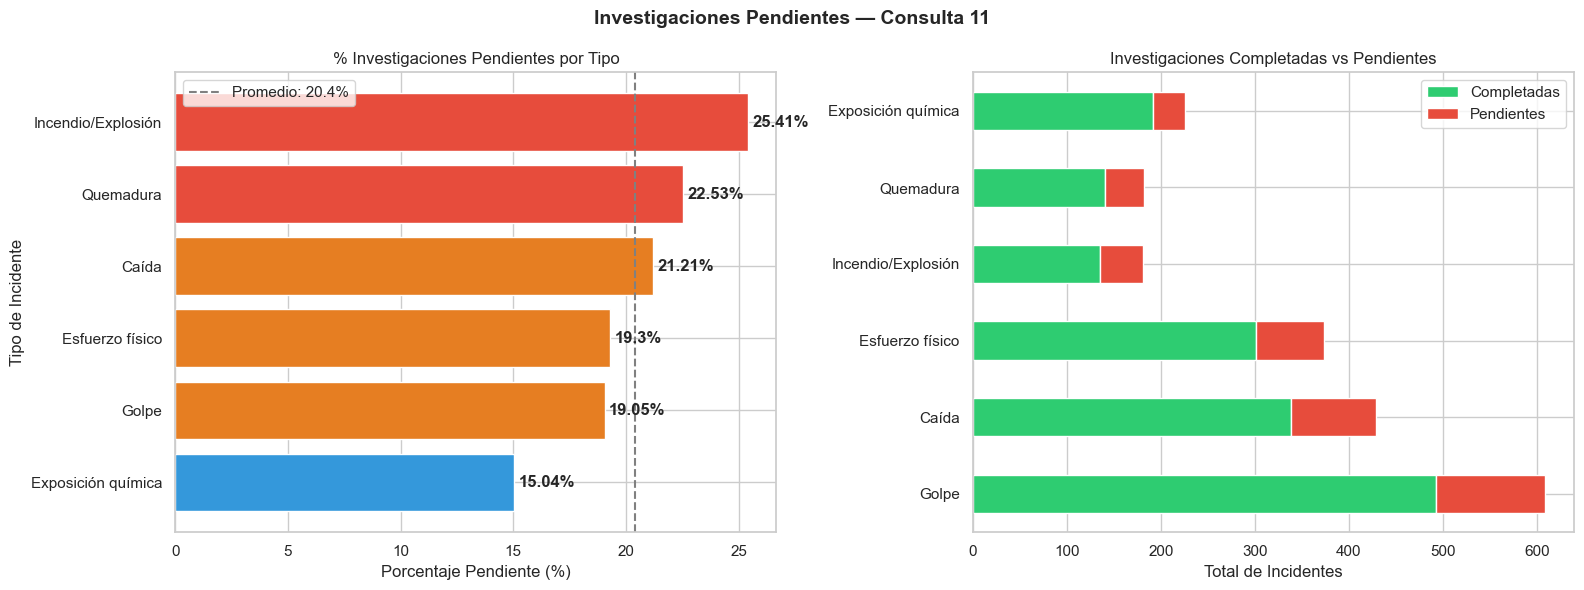

Grafica guardada


In [26]:
# Gráfica investigaciones pendientes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ordenar por pct_pendiente
df_11_sorted = df_11.sort_values('pct_pendiente', ascending=True)

colores_inv = ['#e74c3c' if r == 1 else '#e67e22' if p > 20 else '#3498db'
               for r, p in zip(df_11_sorted['requiere_investigacion'],
                               df_11_sorted['pct_pendiente'])]

# Gráfica 1: Porcentaje pendiente
bars = axes[0].barh(df_11_sorted['tipo_incidente'], df_11_sorted['pct_pendiente'],
                    color=['#e74c3c' if p > 22 else '#e67e22' if p > 19 else '#3498db'
                           for p in df_11_sorted['pct_pendiente']],
                    edgecolor='white')

axes[0].axvline(x=df_11['pct_pendiente'].mean(), color='gray',
                linestyle='--', linewidth=1.5,
                label=f"Promedio: {df_11['pct_pendiente'].mean():.1f}%")

for bar, pct in zip(bars, df_11_sorted['pct_pendiente']):
    axes[0].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{pct}%', va='center', fontweight='bold')

axes[0].set_title('% Investigaciones Pendientes por Tipo')
axes[0].set_xlabel('Porcentaje Pendiente (%)')
axes[0].set_ylabel('Tipo de Incidente')
axes[0].legend()

# Gráfica 2: Total pendientes vs completadas
df_11['completadas'] = df_11['total_incidentes'] - df_11['pendientes']
df_11_plot = df_11[['tipo_incidente', 'completadas', 'pendientes']].set_index('tipo_incidente')

df_11_plot.plot(kind='barh', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                edgecolor='white', stacked=True)
axes[1].set_title('Investigaciones Completadas vs Pendientes')
axes[1].set_xlabel('Total de Incidentes')
axes[1].set_ylabel('')
axes[1].legend(['Completadas', 'Pendientes'])

plt.suptitle('Investigaciones Pendientes — Consulta 11', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('resultados/grafica_11_investigaciones.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

### Hallazgos — Investigaciones Pendientes

- **Incendio/Explosión** tiene el mayor porcentaje de investigaciones pendientes con 25.41%, siendo además el tipo de incidente que por normativa siempre requiere investigación completa. Esto representa un riesgo legal y operativo significativo.
- **Quemadura** ocupa el segundo lugar con 22.53% de pendientes, también un tipo que requiere investigación obligatoria.
- **Exposición química** es el tipo con menor porcentaje pendiente (15.04%), mostrando mejor seguimiento en ese tipo de casos.
- En términos de volumen absoluto, **Golpe** tiene el mayor número de investigaciones pendientes (116) por ser el tipo más frecuente, aunque su porcentaje relativo está por debajo del promedio.
- El promedio general de investigaciones pendientes es 20.4%, lo que significa que 1 de cada 5 incidentes no tiene su investigación cerrada, dejando sin identificar las causas raíz y aumentando el riesgo de reincidencia.

---

## 12. Resumen Ejecutivo por Área

Consolidación de todos los KPIs en una sola vista por área: costo total, incidentes graves, reincidencia y ranking final. Esta consulta combina múltiples CTEs y representa el entregable principal del análisis.

---

In [27]:
# Cargar resultado consulta 12
df_12 = pd.read_csv(ruta + 'resultado_12_resumen_ejecutivo.csv')

print("Datos cargados:")
df_12

Datos cargados:


,area,total_incidentes,costo_total,promedio_dias_perdidos,total_graves,pct_graves,total_reincidencias,pct_reincidencia,ranking_costo
0,Mantenimiento,269,11514789.99,8.17,61,22.68,73,27.14,1
1,Oficinas,268,10066797.81,7.59,51,19.03,79,29.48,2
2,Perforación,250,10059607.64,7.88,46,18.40,69,27.60,3
3,Laboratorio,229,9320740.88,8.38,47,20.52,62,27.07,4
4,Transporte,249,8156035.75,6.49,45,18.07,69,27.71,5
5,Producción,246,7588315.32,6.81,39,15.85,77,31.30,6
6,Construcción,253,7576268.32,6.95,50,19.76,66,26.09,7
7,Almacén,236,7555630.51,6.10,42,17.80,58,24.58,8


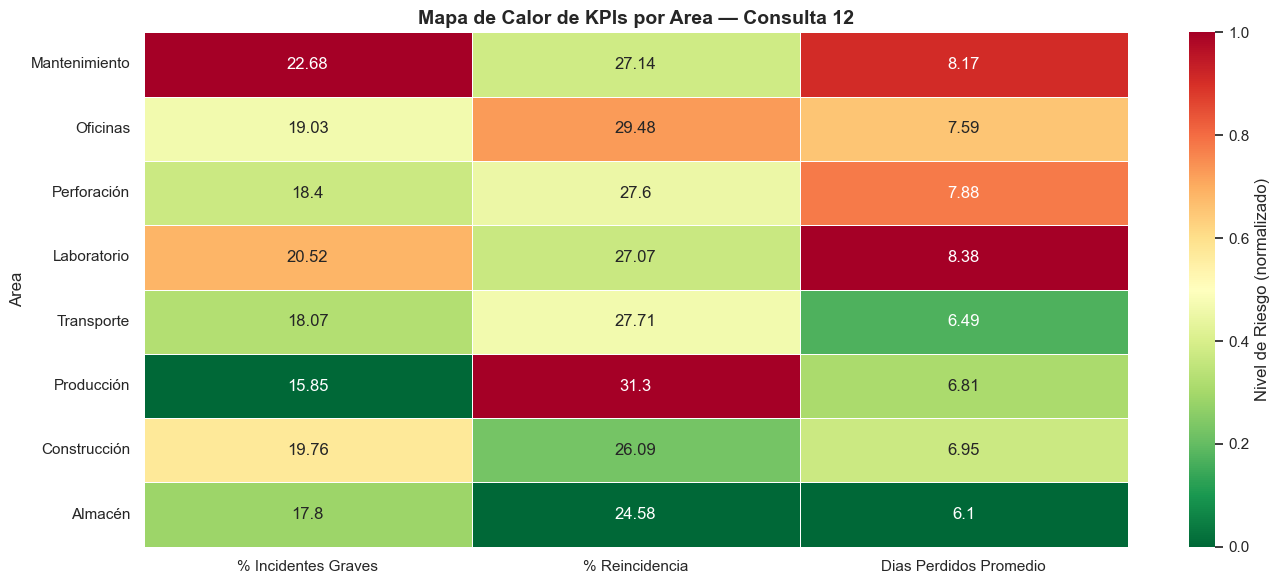

Grafica guardada


In [28]:
# Gráfica resumen ejecutivo — mapa de calor
fig, ax = plt.subplots(figsize=(14, 6))

# Seleccionar métricas clave para el heatmap
df_heat = df_12[['area', 'pct_graves', 'pct_reincidencia', 'promedio_dias_perdidos']].set_index('area')
df_heat.columns = ['% Incidentes Graves', '% Reincidencia', 'Dias Perdidos Promedio']

# Normalizar para comparación visual
df_norm = (df_heat - df_heat.min()) / (df_heat.max() - df_heat.min())

sns.heatmap(
    df_norm,
    annot=df_heat.round(2),
    fmt='g',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Nivel de Riesgo (normalizado)'}
)

ax.set_title('Mapa de Calor de KPIs por Area — Consulta 12', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Area')

plt.tight_layout()
plt.savefig('resultados/grafica_12_resumen_ejecutivo.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafica guardada")

### Hallazgos — Resumen Ejecutivo

- **Mantenimiento** es el área de mayor riesgo global: lidera en % de incidentes graves (22.68%) y días perdidos promedio (8.17), con un costo total que supera los 11.5 millones MXN.
- **Producción** presenta el perfil de riesgo más complejo: menor tasa de incidentes graves (15.85%) pero la reincidencia más alta (31.3%), indicando problemas sistémicos en la aplicación de medidas correctivas.
- **Laboratorio** combina pocos incidentes con alta severidad, reflejado en 8.38 días perdidos promedio, el segundo más alto del análisis.
- **Almacén** mantiene el mejor desempeño en los tres KPIs, siendo el área de referencia para buenas prácticas.
- El mapa de calor revela que ningún área es completamente segura: todas presentan al menos un KPI en nivel de riesgo alto.

---

## Conclusiones Generales

- El costo total de incidentes HSE en el periodo 2022–2024 superó los **60 millones MXN**, con una tendencia de crecimiento sostenido.
- La reincidencia promedio del **27.6%** indica una falla sistémica en el cierre de acciones correctivas en toda la organización.
- El **20.4%** de investigaciones pendientes deja sin identificar causas raíz que podrían prevenir futuros incidentes.
- Las intervenciones prioritarias deben focalizarse en **Mantenimiento** (costo y gravedad) y **Producción** (reincidencia).
- Este análisis demuestra el valor del SQL avanzado combinado con Python para transformar datos operativos en inteligencia de negocio accionable.

---

*Análisis desarrollado como parte del portafolio de Data Analytics — Sergio Ulises Corona Sánchez*